## Manual regularization

In [7]:
import pandas as pd 
df=pd.read_csv(r"C:\Users\indun\Downloads\archive (7)\CarPrice_Assignment.csv")


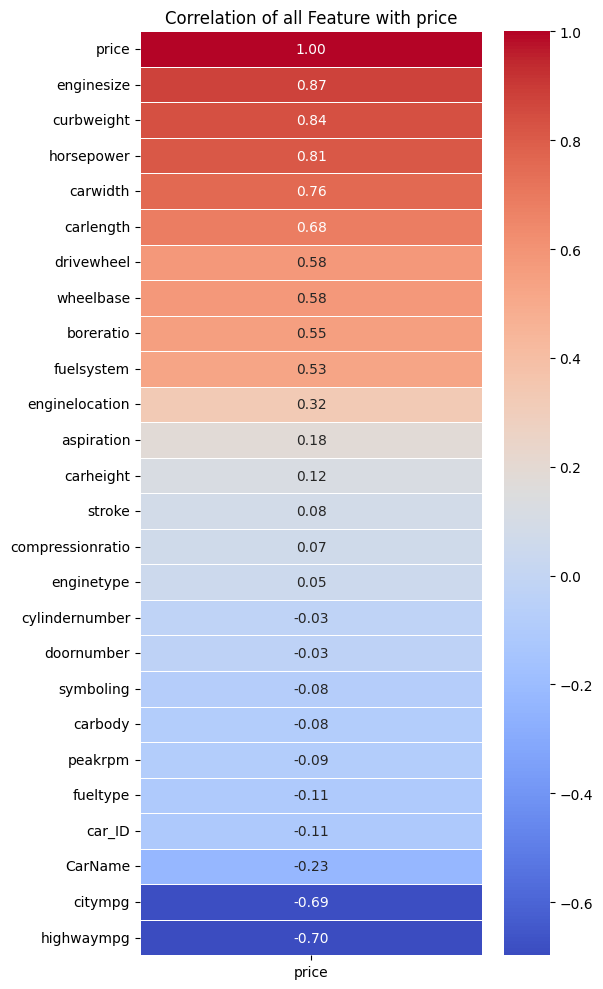

In [13]:

import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df_enc=df.copy()
le=LabelEncoder()
for c in df_enc.columns:
    if df_enc[c].dtype=='object':
        df_enc[c]=le.fit_transform(df_enc[c])

price_corr=df_enc.corr()[['price']].sort_values(by='price',ascending=False)

#heatmap

plt.figure(figsize=(6,10))
sns.heatmap(price_corr,annot=True,cmap="coolwarm",fmt=".2f",linewidth=0.5)
plt.title("Correlation of all Feature with price")
plt.tight_layout()
plt.show()

In [11]:
X = df_model.drop('price', axis=1)
y = df_model['price']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# scores
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R² Score:", train_score)
print("Test R² Score:", test_score)

NameError: name 'df_model' is not defined

## Realtion with price(target)
highwaympg->strongly negative(-0.70)

citympg->strongly negative(-0.69)

carname->moderately negative(-0.23)

car_id->weakly negative(-0.11)

fueltype->weakly negative(-0.11)

peakrpm->weakly negative(-0.09)

carbody->weakly negative(-0.08)

symboling->weakly negative(-0.08)

doornumber->weakly negative(-0.03)

cylindernumber->weakly negative(-0.03)

enginetype->weakly positive(0.05)

compressionratio->weakly positive(0.07)

stroke->weakly positive(0.08)

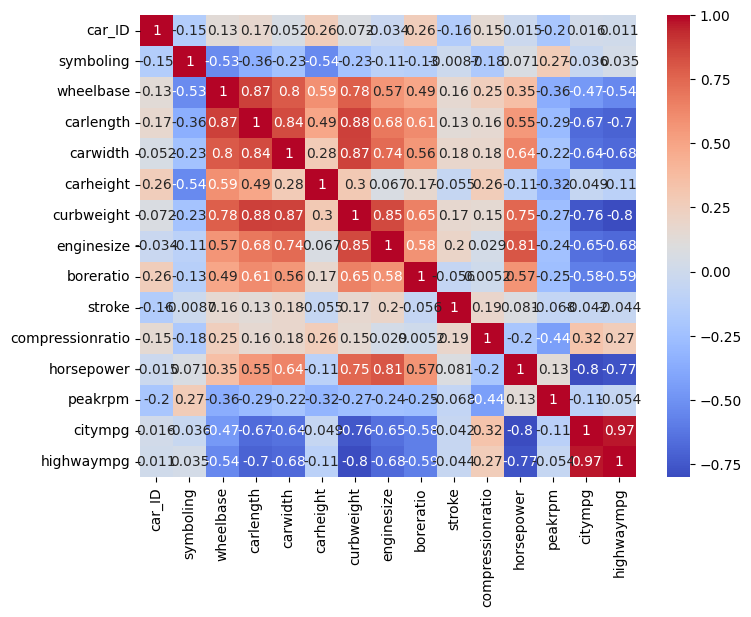

In [10]:
## Analysing feature to feature relationship
x=df.drop('price',axis=1)

import seaborn as sns
import matplotlib.pyplot as pyplot
plt.figure(figsize=(8,6))
sns.heatmap(x.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

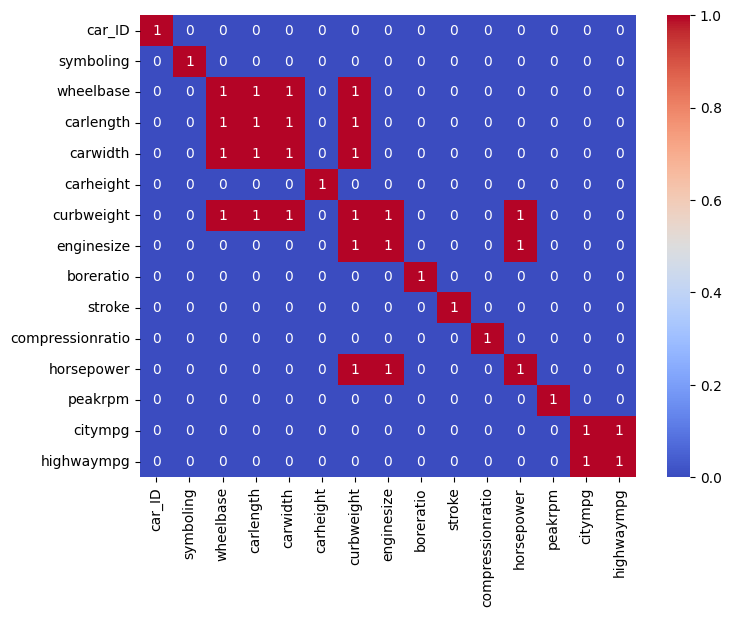

In [12]:
## Multicollinearity

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(x.corr(numeric_only=True)>0.75,annot=True,cmap='coolwarm')
plt.show()

## Muticollinearity between features
wheelbase-->carlength(0.87)

wheelbase-->carwidth(0.8)

wheelbase-->curbweight(0.78)

carlength-->carwidth(0.84)

carlength-->curbweight(0.88)

carwidth-->curbweight(0.87)

curbweight-->enginesize(0.85)

curbweight-->horsepower(0.75)

enginesize-->horsepower(0.81)

citympg-->highwaympg(0.97)

In [ ]:
### Remove features that have multicollinearity and less correlation with target to remove noise and columns with less correlation with price.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
df_model=df.copy()
le=LabelEncoder()
for col in df_model.columns:
    if df_model[col].dtype=='object':
        df_model[col]=le.fit_transform(df_model[col])



Drop due to high multicollinearity

(keep only one from each highly correlated group)

Vehicle size group (keep curbweight only):

❌ wheelbase

❌ carlength

❌ carwidth

Engine power group (keep enginesize):

❌ horsepower

Mileage group (keep citympg):

❌ highwaympg (very high corr = 0.97 with citympg)

🟡 Drop due to very weak relation with price

(these add noise)

❌ car_id

❌ carname

❌ doornumber

❌ symboling

❌ fueltype

❌ peakrpm

❌ carbody

❌ cylindernumber

✅ Final features to KEEP

curbweight

enginesize

citympg

enginetype

compressionratio

stroke


In [ ]:
df_model.drop(columns=['doornumber','cylindernumber','enginetype','compressionratio','wheelbase','carlength','carwidth','horsepower','highwaympg','car_ID','CarName','peakrpm','carbody'] ,inplace=True)
x=df_model.drop('price',axis=1)
y=df_model['price']
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
train_score=model.score(X_train,y_train)
test_score=model.score(X_test,y_test)
print("Train R2 score:",train_score)
print("Test r2 score:",test_score)


Train R2 score: 0.8588385979748207
Test r2 score: 0.8255532594848818


## Ridge and Lasso Regression



In [ ]:
from sklearn.model_selection import train_test_split
x=df[['enginesize']]
y=df['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
print("Ridge Regression")
alphas=np.arange(0.1,10,0.05)
ridge=RidgeCV(alphas=alphas)
ridge.fit(X_train,y_train)
print("BEst alpha",ridge.alpha_)
y_pred=ridge.predict(X_test)
train_score=ridge.score(X_train,y_train)
test_score=ridge.score(X_test,y_test)
print("Training score (R²):", train_score)
print("Testing score (R²):", test_score)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)



Ridge Regression
BEst alpha 0.3500000000000001
Training score (R²): 0.9089305340239424
Testing score (R²): 0.8522837933318043
MSE: 11661311.30347787
